In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from nemosis import dynamic_data_compiler
from mpl_toolkits.mplot3d import Axes3D
import os


os.makedirs('../data/nemosis_cache', exist_ok=True)
CACHE = '../data/nemosis_cache'


# DISPATCHPRICE: 5-minute settlement prices for each NEM region.
# INTERVENTION=0 filters out intervention pricing — during network interventions
# AEMO sets prices via constraint equations, which distort the market signal.
# Keeping only INTERVENTION=0 gives you the "true" dispatch prices.
prices = dynamic_data_compiler(
    '2025/01/01 00:00:00',
    '2026/01/01 00:00:00',
    'DISPATCHPRICE', CACHE,
    fformat='parquet',
    filter_cols=['INTERVENTION'],
    filter_values=([0],)
)

prices = prices[['SETTLEMENTDATE', 'REGIONID', 'RRP', 'PRICE_STATUS']].copy()

# SETTLEMENTDATE is the *end* of the dispatch interval (e.g. 00:05 covers 00:00–00:05).
# Subtract 5 minutes here — once, on the raw data — so that both derived DataFrames
# share a consistent interval-start index without needing separate post-pivot shifts.
prices['SETTLEMENTDATE'] = prices['SETTLEMENTDATE'] - pd.Timedelta('5min')

print(prices.head(20))

# Pivot to wide format (rows = timestamps, columns = regions).
# This is the primary DataFrame used in all subsequent analysis.
prices_wide = (prices
    .pivot(index='SETTLEMENTDATE', columns='REGIONID', values='RRP')
    .sort_index()
)

# Same shape/index as prices_wide — used to mask administered pricing periods.
# PRICE_STATUS is 'FIRM' under normal conditions, 'ADMINISTERED' when AEMO
# sets prices outside the normal market mechanism (e.g. during price cap events).
price_status_wide = (prices
    .pivot(index='SETTLEMENTDATE', columns='REGIONID', values='PRICE_STATUS')
    .sort_index()
)

print()
print(prices_wide.head())
print(f"Shape: {prices_wide.shape}")
print(f"Memory: {prices_wide.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Expect all FIRM for 2025 — if ADMINISTERED shows up here, those periods
# will be highlighted in the administered pricing overlay cell below.
print("\nPRICE_STATUS value counts (all regions):")
print(price_status_wide.apply(pd.Series.value_counts).fillna(0).astype(int))

# Market price cap (MPC) is ~$15,100/MWh. Hitting the cap indicates a
# severe supply shortage. A handful of cap events per year is normal for SA.
print("\nHow many price cap intervals were there?")
cap_events = (prices_wide >= 15000).sum()
print(cap_events)

# Negative prices occur when supply exceeds demand and generators bid negative
# to stay on-line (e.g. wind farms avoiding ramp costs, solar avoiding curtailment).
# SA and QLD typically lead on negative price count due to high renewable penetration.
print("\nHow many negative price intervals?")
neg_prices = (prices_wide < 0).sum()
print(neg_prices)

print(prices_wide.describe())

INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
        SETTLEMENTDATE REGIONID        RRP PRICE_STATUS
0  2025-01-01 00:00:00     NSW1  138.02790         FIRM
1  2025-01-01 00:00:00     QLD1  154.30294         FIRM
2  2025-01-01 00:00:00      SA1  141.47720         FIRM
3  2025-01-01 00:00:00     TAS1  125.17761         FIRM
4  2025-01-01 00:00:00     VIC1  130.00000         FIRM
5  2025-01-01 00:05:00     NSW1  134.41651         FIRM
6  2025-01-01 00:05:00     QLD1  150.42180         FIRM
7  2025-01-01 00:05:00      SA1  136.58563         FIRM
8  2025-01-01 00:05:00     TAS1  120.28000         FIRM
9  2025-01-01 00:05:00     VIC1  125.50000         FIRM
10 2025-01-01 00:10:00     NSW1  135.89000         FIRM
11 2025-01-01 00:10:00     QLD1  150.07326         FIRM
12 2025-01-01 00:10:00      SA1  142.05217         FIRM
13 2025-01-01 00:10:00     TAS1  129.97176         FIRM
14 2025-01-01 00:10:00     VIC1  129.02340         FIRM
15 2025-01-01 00:15:00     N

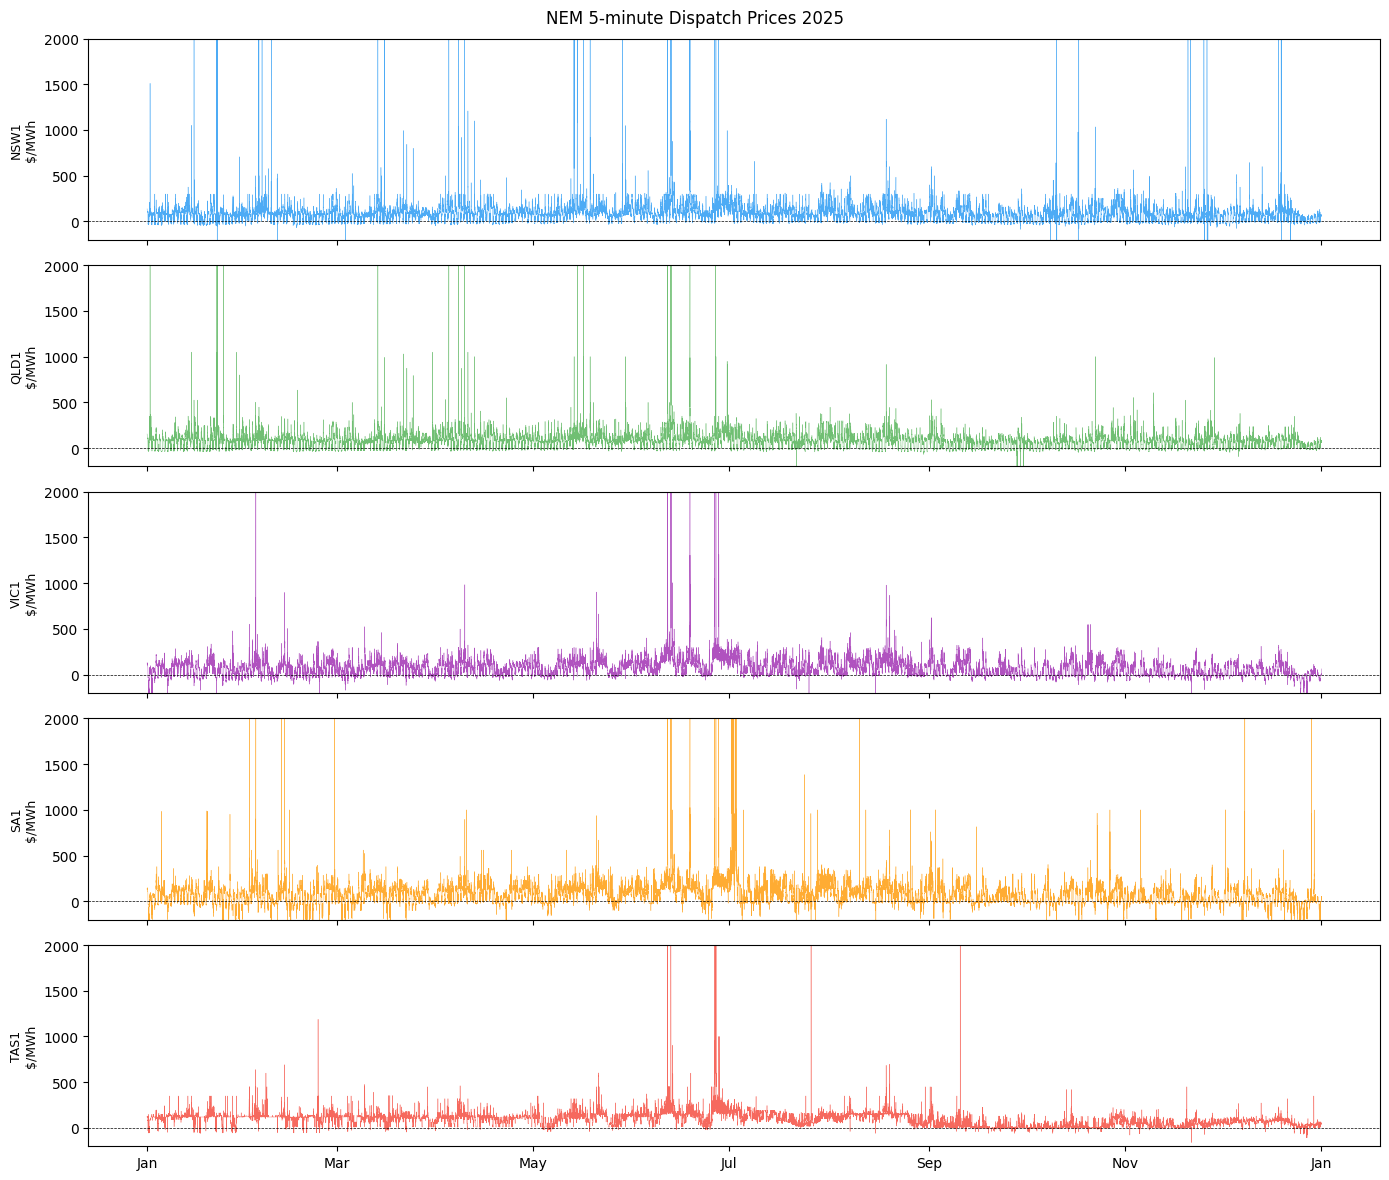

In [35]:
# Time Series Plot
# Full-year view of 5-minute prices for each region.
# Useful for spotting seasonal patterns, price spike clusters, and periods of
# sustained negative prices. Prices are capped at $2,000 for display — above
# this, the series becomes unreadable due to MPC spike outliers.
# The dashed zero line makes negative price periods immediately visible.

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
regions = ['NSW1', 'QLD1', 'VIC1', 'SA1', 'TAS1']
colors  = ['#2196F3', '#4CAF50', '#9C27B0', '#FF9800', '#F44336']

for ax, region, color in zip(axes, regions, colors):
    # Cap display at $2,000 for readability — spikes exist but collapse the y-axis
    display = prices_wide[region].clip(upper=2000)
    ax.plot(display.index, display, lw=0.3, color=color, alpha=0.8)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.set_ylabel(f'{region}\n$/MWh', fontsize=9)
    ax.set_ylim(-200, 2000)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.suptitle('NEM 5-minute Dispatch Prices 2025', fontsize=12)
plt.tight_layout()

Text(0.98, 0.02, 'Intervals > $500 clipped — NSW1: 443  QLD1: 222  VIC1: 363  SA1: 646  TAS1: 166')

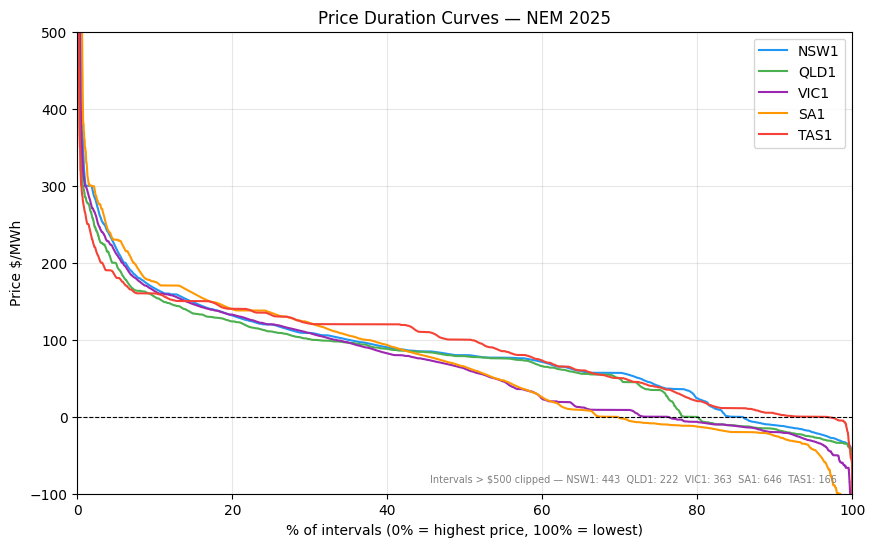

In [36]:
# Price Duration Curve (PDC)
# A PDC sorts all price observations from highest to lowest and plots them
# against the fraction of time that price was exceeded. Reading the chart:
#   - The left tail shows how severe and frequent price spikes are.
#   - Where the curve crosses $0 shows what fraction of time prices are negative.
#   - A steep left tail → volatile market with infrequent but large spikes (SA).
#   - A flat, low curve → stable, low-priced market (TAS, typically hydro-dominated).
# Y-axis is clipped at $500 to show the bulk of the distribution — spike counts
# are annotated so the clipped data isn't hidden.

fig, ax = plt.subplots(figsize=(10, 6))

for region, color in zip(regions, colors):
    sorted_prices = prices_wide[region].sort_values(ascending=False).values
    pct = (np.arange(len(sorted_prices)) / len(sorted_prices)) * 100  # x-axis: % of intervals
    ax.plot(pct, sorted_prices, label=region, color=color, lw=1.5)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlim(0, 100)
ax.set_ylim(-100, 500)   # zoom in on the bulk — spikes distort the top
ax.set_xlabel('% of intervals (0% = highest price, 100% = lowest)')
ax.set_ylabel('Price $/MWh')
ax.set_title('Price Duration Curves — NEM 2025')
ax.legend()
ax.grid(alpha=0.3)

# Show what's being clipped — the spikes are part of the story
clip_counts = {r: int((prices_wide[r] > 500).sum()) for r in regions}
clip_note = '  '.join(f'{r}: {n}' for r, n in clip_counts.items() if n > 0)
ax.text(0.98, 0.02, f'Intervals > $500 clipped — {clip_note}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=7, color='gray')

/tmp/ipykernel_135074/4169489779.py:71: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


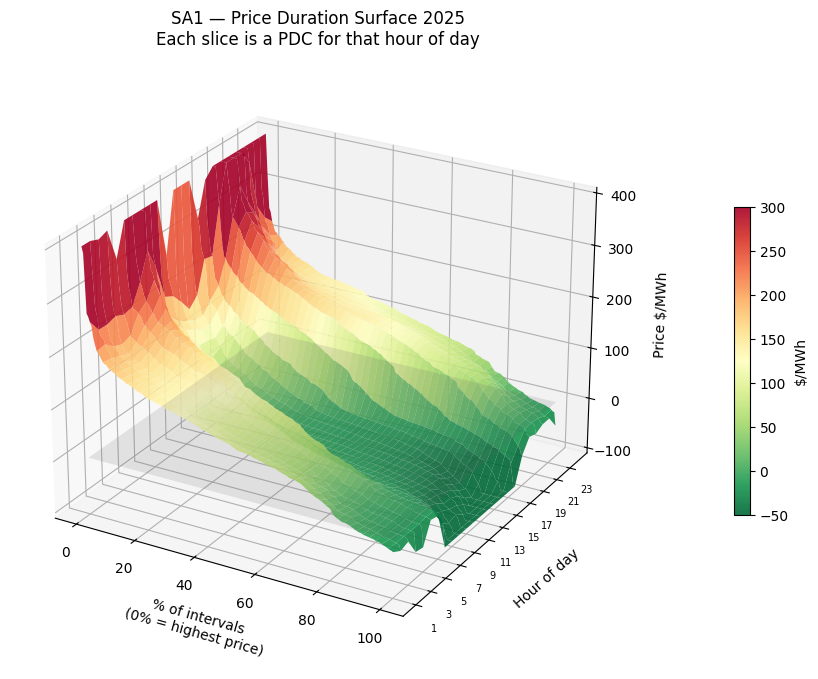

In [37]:
# 3D Price Duration Surface — by hour of day (SA1)
# Each horizontal slice through this surface is the PDC for a specific hour.
# Reading the surface:
#   - Y-axis (hour of day): look for how the shape changes between morning,
#     midday, and evening. Solar hours (10:00–15:00) should show a deep trough
#     in the centre of the surface (cheap/negative midday prices).
#   - X-axis (% of intervals): leftmost edge = highest prices, rightmost = lowest.
#   - Z-axis ($/MWh): height of the surface = price level at that percentile/hour.
#   - The grey zero plane makes it easy to see which hour/percentile combinations
#     produce negative prices (surface drops below the plane).
# Z is clipped at ±400 for visual clarity — extreme spike outliers would otherwise
# compress the rest of the surface into a flat floor.

region = 'SA1'

# Work with hourly data
prices_hourly = prices_wide.resample('1h').mean()
df = prices_hourly[[region]].copy()
df['hour'] = df.index.hour + 1   # 1–24
df = df[df[region] > -500]       # drop extreme outliers for surface clarity

# For each hour bucket, compute a sorted price duration array
# We'll use percentile points as the "duration" axis
percentiles = np.linspace(0, 100, 200)
hours = list(range(1, 25))

# Build matrix: rows = hours (24), cols = percentile points (200)
# Value = price at that percentile for that hour
Z = np.zeros((len(hours), len(percentiles)))

for i, h in enumerate(hours):
    hour_prices = df[df['hour'] == h][region].dropna().values
    if len(hour_prices) > 0:
        # Sort descending (like a PDC — 0th percentile = highest price)
        Z[i, :] = np.percentile(hour_prices, 100 - percentiles)

# Meshgrid for surface
X, Y = np.meshgrid(percentiles, hours)  # X = % of intervals, Y = hour of day

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Clip Z for visual clarity — spikes collapse the surface otherwise
Z_display = np.clip(Z, -100, 400)

surf = ax.plot_surface(
    X, Y, Z_display,
    cmap='RdYlGn_r',
    vmin=-50, vmax=300,
    alpha=0.9,
    linewidth=0,
    antialiased=True
)

# Add zero plane for reference
xx, yy = np.meshgrid([0, 100], [1, 24])
ax.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.15, color='grey')

ax.set_xlabel('% of intervals\n(0% = highest price)', labelpad=10)
ax.set_ylabel('Hour of day', labelpad=10)
ax.set_zlabel('Price $/MWh', labelpad=10)
ax.set_title(f'{region} — Price Duration Surface 2025\n'
             f'Each slice is a PDC for that hour of day')
ax.set_yticks(range(1, 25, 2))
ax.set_yticklabels(range(1, 25, 2), fontsize=7)

# Good viewing angle — adjust to taste
ax.view_init(elev=25, azim=-60)

plt.colorbar(surf, ax=ax, label='$/MWh', shrink=0.5, pad=0.1)
plt.tight_layout()
plt.show()

In [ ]:
# Daily price distribution ribbon — SA1
# The ribbon spans P10–P90 (80% of hours each day); the line is the daily median.
#
# Reading the chart:
#   - Narrow ribbon = low intra-day spread (stable generation mix that day)
#   - Wide ribbon   = large cheap-midday / expensive-peak spread (solar duck curve days)
#   - Ribbon dipping below $0 = negative prices occurred that day
#   - Seasonal clusters of wide ribbons → typically summer demand peaks and spring solar surplus

region = 'SA1'

# Filter to one region before resampling — avoids resampling 4 unused columns
daily = (prices_wide[region]
         .resample('1h').mean()
         .resample('D').quantile([0.1, 0.5, 0.9])
         .unstack())
daily.columns = ['p10', 'median', 'p90']

CLIP_LO, CLIP_HI = -200, 800
daily_plot = daily.clip(CLIP_LO, CLIP_HI)  # clip once, reuse in all three plot calls

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_plot.index, daily_plot['p10'], daily_plot['p90'],
                alpha=0.3, color='steelblue', label='P10–P90 range')
ax.plot(daily_plot.index, daily_plot['median'],
        color='steelblue', lw=1.0, label='Daily median')
ax.axhline(0, color='black', lw=0.8, ls='--')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_ylabel('Price $/MWh')
ax.set_title(f'{region} — Daily price distribution 2025\n'
             f'Ribbon = P10–P90 of hourly prices each day  |  Line = daily median')
ax.legend(loc='upper right')
ax.set_ylim(CLIP_LO, CLIP_HI)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

n_neg_median = (daily['median'] < 0).sum()
n_wide = (daily['p90'] - daily['p10'] > 200).sum()
print(f"Days with negative median price:       {n_neg_median}")
print(f"Days with P10–P90 spread > $200/MWh:  {n_wide}  (high intra-day volatility)")

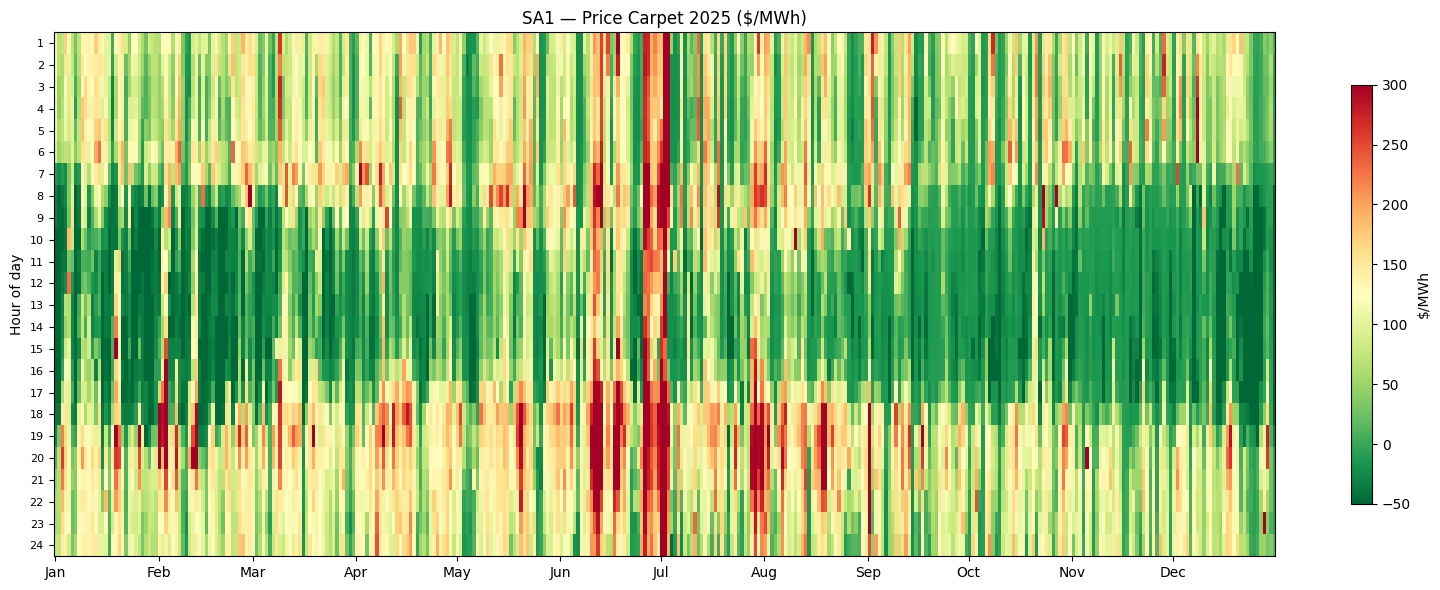

In [39]:
# Price Carpet — SA1
# A carpet plot maps the full year on the x-axis and hours of the day on the y-axis.
# Each cell is coloured by the mean price in that hour on that calendar day.
# This is a dense, information-rich view that makes several patterns visible at once:
#   - Vertical bands of colour → multi-day price events (heatwaves, generator outages).
#   - Horizontal colour gradients → intra-day price shape (cheap midday, expensive morning/evening).
#   - Seasonal colour shift → summer/winter demand differences.
#   - Green patches in midday rows (hours 10–15) → solar surplus driving prices negative.
# Colour scale is clipped at $300 — spike outliers would wash out the gradient otherwise.

region = 'SA1'
prices_hourly = prices_wide.resample('1h').mean()

df = prices_hourly[[region]].copy()
df['hour'] = df.index.hour + 1        # 1–24
df['day_of_year'] = df.index.dayofyear

# Pivot: rows = hour of day, columns = calendar day
pivot = df.pivot_table(
    values=region,
    index='hour',           # y-axis: 1–24
    columns='day_of_year',  # x-axis: 1–365
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(
    pivot,
    aspect='auto',
    cmap='RdYlGn_r',
    vmin=-50, vmax=300,     # clip — don't let spikes dominate colour scale
    interpolation='nearest'
)

# X-axis: label by month
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks([d - 1 for d in month_starts])  # -1 because imshow is 0-indexed
ax.set_xticklabels(month_labels)

ax.set_yticks(range(24))
ax.set_yticklabels(range(1, 25), fontsize=8)
ax.set_ylabel('Hour of day')
ax.set_title(f'{region} — Price Carpet 2025 ($/MWh)')

plt.colorbar(im, label='$/MWh', shrink=0.8)
plt.tight_layout()
plt.show()

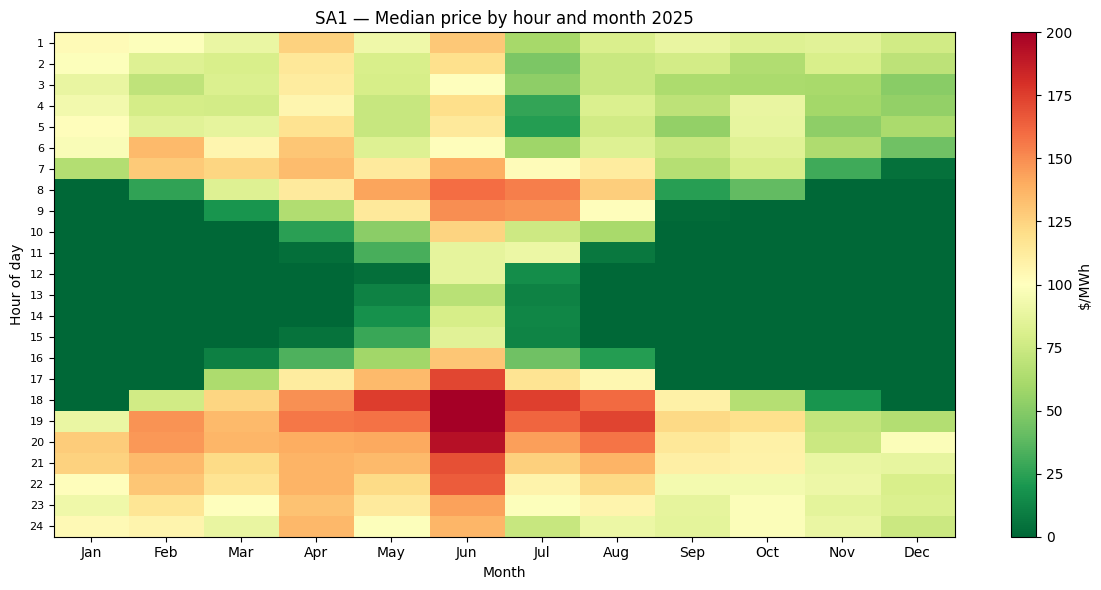

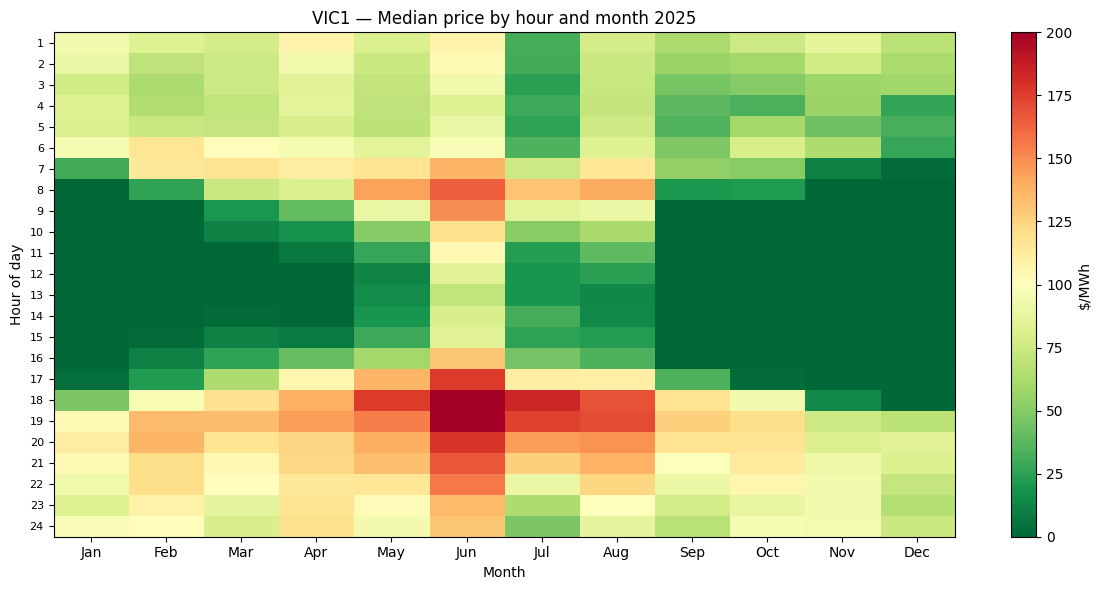

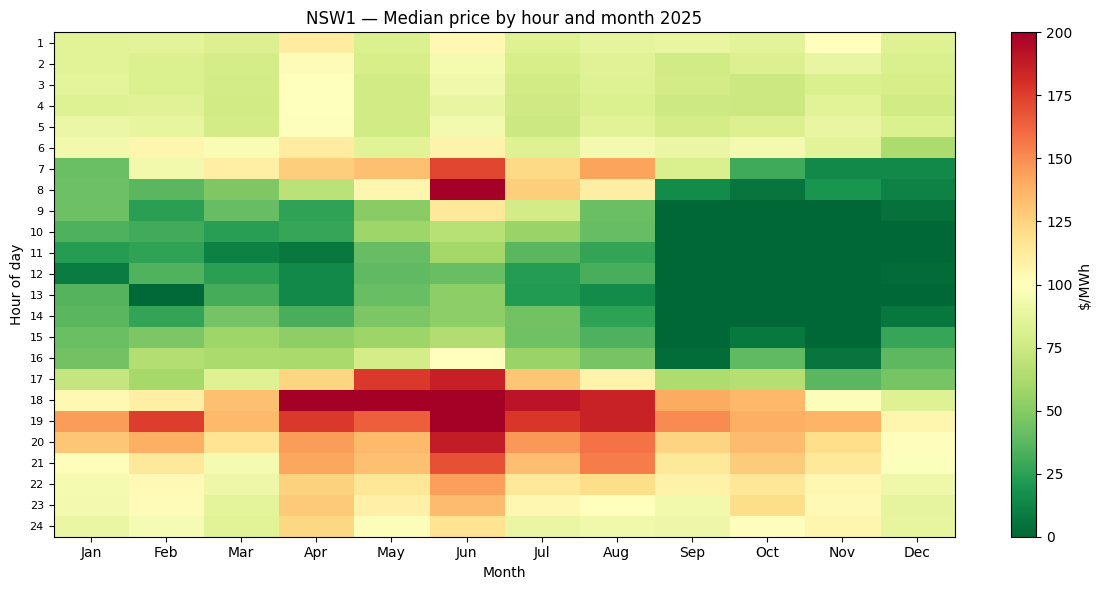

In [40]:
# Median Price Heatmap — by hour of day and month
# Shows the typical intra-day price shape for each month of the year.
# Using median (not mean) to reduce the influence of spike events.
# Reading the chart:
#   - Dark red cells = expensive hours (morning/evening demand peaks).
#   - Green/yellow cells = cheap or negative hours (midday solar, overnight low demand).
#   - Compare months: summer months should show higher afternoon prices in SA/NSW
#     (air conditioning load) while spring/autumn show deeper midday troughs (solar surplus).
# Plotted for SA1, VIC1, and NSW1 to contrast renewable-heavy and gas-peaking markets.

prices_hourly = prices_wide.resample('1h').mean()

for region in ['SA1', 'VIC1', 'NSW1']:
    df = prices_hourly[[region]].copy()
    
    # Hour bucket 1–24 (not 0–23)
    df['hour'] = df.index.hour + 1      # shifts 0-23 → 1-24
    df['month'] = df.index.month
    
    pivot = df.pivot_table(
        values=region,
        index='hour',       # 1–24, 24 rows
        columns='month',
        aggfunc='median'
    )
    
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(pivot, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=200)
    
    ax.set_xlabel('Month')
    ax.set_ylabel('Hour of day')
    ax.set_yticks(range(24))
    ax.set_yticklabels(range(1, 25), fontsize=8)
    ax.set_title(f'{region} — Median price by hour and month 2025')
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.colorbar(im, label='$/MWh')
    plt.tight_layout()
    plt.show()

In [ ]:
# SA–VIC Price Spread
# The spread (SA price minus VIC price) is a proxy for the interconnector margin.
# When SA is more expensive than VIC (positive spread), it suggests:
#   - The Heywood interconnector is importing at capacity (SA is short of supply), or
#   - SA has a local price event (generator trip, high gas prices).
# When VIC is more expensive (negative spread):
#   - SA is exporting, or
#   - SA has excess renewable generation pushing prices down.
#
# Interconnectors have a small unavoidable loss component, so a spread of ~$0–$10
# can exist even with an unconstrained interconnector. Spreads persistently above
# ~$50–$100 are a more reliable proxy for binding interconnector constraints.

spread = prices_wide['SA1'] - prices_wide['VIC1']

# Resample to hourly for the time-series plot only — reduces 105k points to ~8.7k
spread_hourly = spread.resample('1h').mean()
spread_display = spread_hourly.clip(-200, 500)  # clip once, used twice in fill_between

fig, axes = plt.subplots(3, 1, figsize=(12, 11))

# --- Top: spread time series ---
axes[0].fill_between(spread_display.index, spread_display, 0,
                     where=spread_display > 0, alpha=0.5, color='red',  label='SA > VIC')
axes[0].fill_between(spread_display.index, spread_display, 0,
                     where=spread_display < 0, alpha=0.5, color='blue', label='VIC > SA')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('SA–VIC Price Spread 2025 (hourly means, clipped ±$200/$500)')
axes[0].set_ylabel('Spread $/MWh')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].legend(loc='upper right')

# --- Middle: histogram with threshold markers ---
thresholds = [50, 100, 200, 500]
threshold_colors = ['#FFC107', '#FF9800', '#F44336', '#9C27B0']

axes[1].hist(spread.clip(-300, 800), bins=200, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='black', lw=1.5, ls='--', label='$0 (parity)')
for t, c in zip(thresholds, threshold_colors):
    axes[1].axvline(t, color=c, lw=1.2, ls='--', label=f'${t}')
axes[1].set_xlabel('SA - VIC spread $/MWh')
axes[1].set_title('Distribution of SA–VIC spread 2025')
axes[1].set_ylabel('Count (5-min intervals)')
axes[1].legend(loc='upper right', fontsize=8)

# --- Bottom: % of time spread exceeds threshold ---
# Vectorised: single (M×N) boolean matrix instead of 45 separate mask evaluations
threshold_range = list(range(-500, 601, 25))
threshold_arr = np.array(threshold_range)
pct_above = (spread.values > threshold_arr[:, None]).mean(axis=1) * 100
t_idx = {t: i for i, t in enumerate(threshold_range)}

axes[2].plot(threshold_range, pct_above, color='red', lw=1.5, label='% time SA > VIC by >$X')
axes[2].axvline(0, color='black', lw=0.8, ls='--')
for t, c in zip(thresholds, threshold_colors):
    pct = pct_above[t_idx[t]]  # reuse already-computed values
    axes[2].axvline(t, color=c, lw=1, ls=':')
    axes[2].annotate(f'{pct:.1f}%', xy=(t, pct), xytext=(t + 12, pct + 1.5),
                     fontsize=7, color=c)
axes[2].set_xlabel('Spread threshold $/MWh')
axes[2].set_ylabel('% of 5-min intervals')
axes[2].set_title('% of time SA–VIC spread exceeds threshold\n'
                  '(proxy for binding interconnector constraint — $50+ is a practical signal)')
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary table ---
# Vectorised: compute all counts and percentages in two matrix operations
print("SA–VIC spread summary (5-min intervals)\n")
print(f"  Mean spread:    {spread.mean():>8.1f} $/MWh")
print(f"  Median spread:  {spread.median():>8.1f} $/MWh")
print(f"  Std dev:        {spread.std():>8.1f} $/MWh")
print()

pos_t = np.array([0, 10, 50, 100, 200, 500])
pos_mask = spread.values > pos_t[:, None]          # (6, N) — one pass
pos_n, pos_pct = pos_mask.sum(axis=1), pos_mask.mean(axis=1) * 100

print("  Interconnector constraint proxy (SA > VIC by threshold):")
for t, n, pct in zip(pos_t, pos_n, pos_pct):
    print(f"    > ${t:>4}: {pct:5.1f}% of intervals  ({n:>6} intervals, {n*5/60:>5.0f} hrs)")

neg_t = np.array([10, 50, 100, 200])
neg_mask = spread.values < -neg_t[:, None]         # (4, N) — one pass
neg_n, neg_pct = neg_mask.sum(axis=1), neg_mask.mean(axis=1) * 100

print()
print("  VIC > SA (negative spread, SA exporting or oversupplied):")
for t, n, pct in zip(neg_t, neg_n, neg_pct):
    print(f"    > ${t:>4}: {pct:5.1f}% of intervals  ({n:>6} intervals, {n*5/60:>5.0f} hrs)")

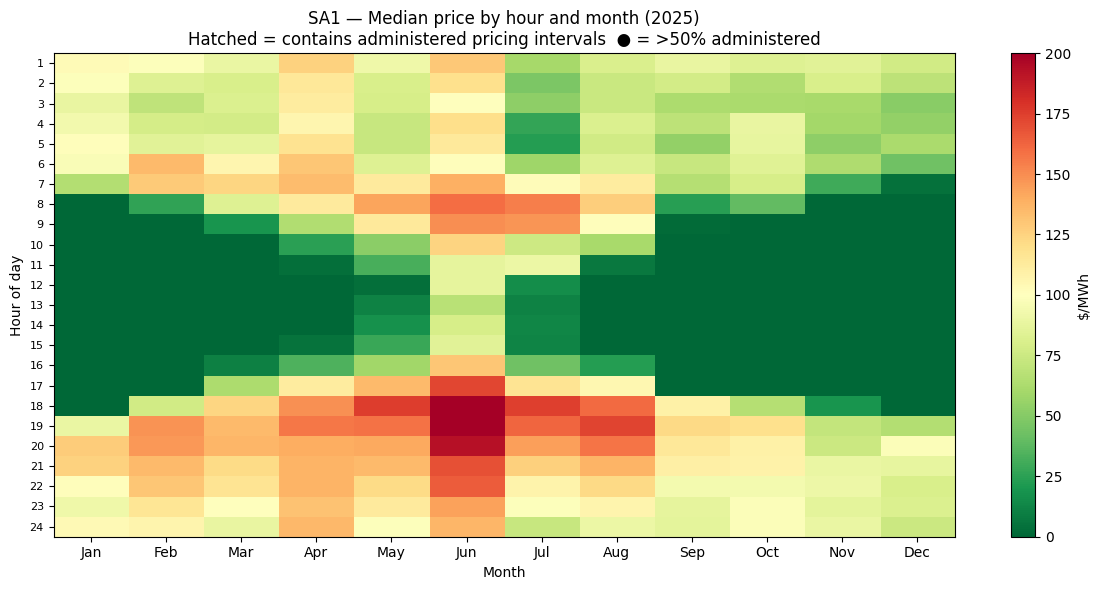

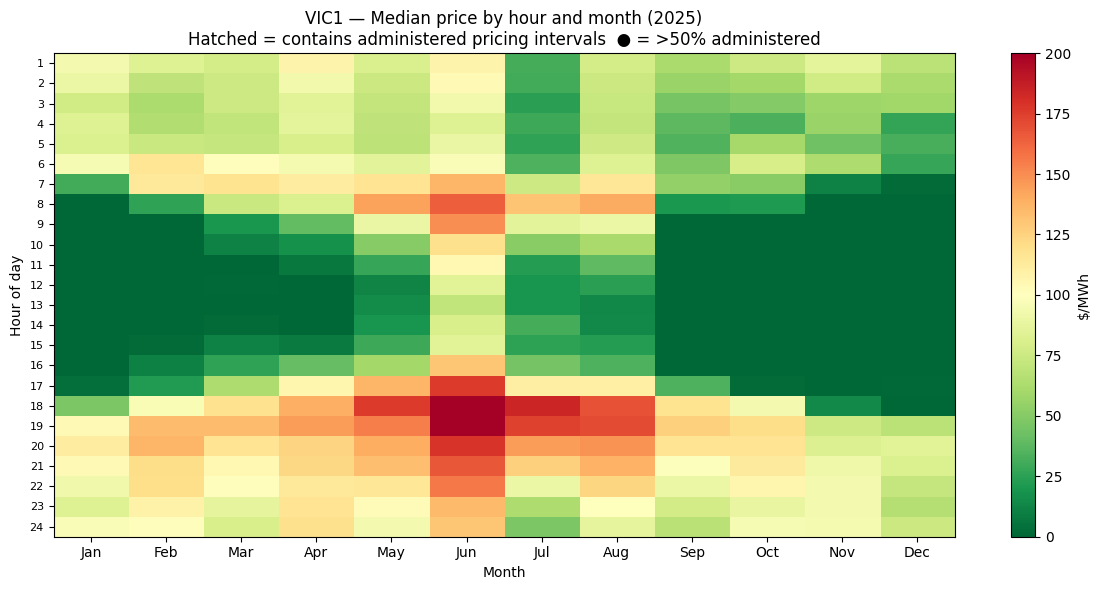


Administered pricing summary by region:
  NSW1: no administered intervals
  QLD1: no administered intervals
  SA1: no administered intervals
  TAS1: no administered intervals
  VIC1: no administered intervals


In [42]:
# Administered Pricing Overlay
# When cumulative prices in a region exceed the Cumulative Price Threshold (CPT)
# over a rolling 7-day window, AEMO activates administered pricing. During this period
# prices are set at the Administered Price Cap (APC, ~$300/MWh) rather than by the market.
# This protects consumers from sustained high prices but can mask the true supply signal.
#
# This cell overlays administered periods (hatched) on the median price heatmap so you
# can see both what prices looked like AND when they were market-set vs administered.
# A '●' marker indicates cells where >50% of the hours were under administered pricing.

# Resample prices to hourly
prices_hourly = prices_wide.resample('1h').mean()

# For status: an hour is "administered" if ANY interval within it was administered
# Convert to boolean first (True = administered), then resample with max (any=True → True)
administered_bool = (price_status_wide != 'FIRM')
administered_hourly = administered_bool.resample('1h').max()  # True if any 5-min was administered

for region in ['SA1', 'VIC1']:
    df = prices_hourly[[region]].copy()
    df['hour'] = df.index.hour + 1
    df['month'] = df.index.month

    # Same shape pivot for the administered mask
    adm = administered_hourly[[region]].copy()
    adm['hour'] = adm.index.hour + 1
    adm['month'] = adm.index.month

    pivot = df.pivot_table(
        values=region, index='hour', columns='month', aggfunc='median'
    )
    
    # Fraction of hours in each (hour, month) cell that were administered
    adm_pivot = adm.pivot_table(
        values=region, index='hour', columns='month', aggfunc='mean'
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(pivot, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=200)

    # Hatch over cells where any hours were administered; dot where majority were
    for row_idx in range(24):
        for col_idx in range(12):
            month = col_idx + 1
            hour = row_idx + 1
            if month in adm_pivot.columns and hour in adm_pivot.index:
                frac = adm_pivot.loc[hour, month]
                if frac > 0:
                    ax.add_patch(plt.Rectangle(
                        (col_idx - 0.5, row_idx - 0.5), 1, 1,
                        fill=False, hatch='////', edgecolor='white',
                        linewidth=0, alpha=0.8
                    ))
                    if frac > 0.5:
                        ax.text(col_idx, row_idx, '●', ha='center', va='center',
                                color='white', fontsize=6)

    ax.set_xlabel('Month')
    ax.set_ylabel('Hour of day')
    ax.set_yticks(range(24))
    ax.set_yticklabels(range(1, 25), fontsize=8)
    ax.set_title(f'{region} — Median price by hour and month (2025)\n'
                 f'Hatched = contains administered pricing intervals  ● = >50% administered')
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.colorbar(im, label='$/MWh')
    plt.tight_layout()
    plt.show()

# Summary: which regions saw administered pricing and over what date range
print("\nAdministered pricing summary by region:")
for region in ['NSW1', 'QLD1', 'SA1', 'TAS1', 'VIC1']:
    n_intervals = administered_bool[region].sum()
    if n_intervals > 0:
        adm_times = price_status_wide.index[administered_bool[region]]
        print(f"  {region}: {n_intervals} intervals | "
              f"{adm_times.min().date()} → {adm_times.max().date()}")
    else:
        print(f"  {region}: no administered intervals")

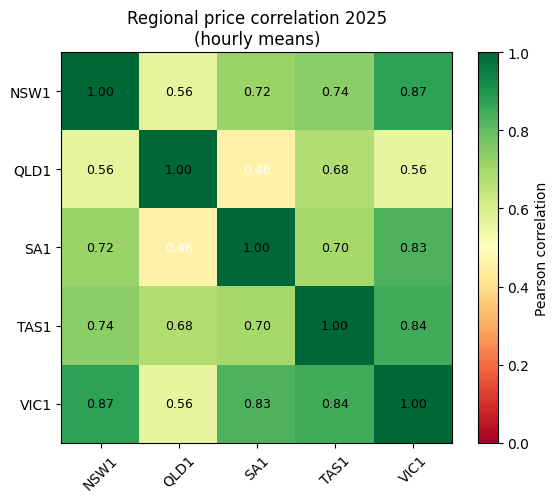

REGIONID      NSW1      QLD1       SA1      TAS1      VIC1
REGIONID                                                  
NSW1      1.000000  0.562724  0.717862  0.738923  0.872458
QLD1      0.562724  1.000000  0.459735  0.677576  0.560762
SA1       0.717862  0.459735  1.000000  0.697510  0.831557
TAS1      0.738923  0.677576  0.697510  1.000000  0.844879
VIC1      0.872458  0.560762  0.831557  0.844879  1.000000


In [43]:
# Regional price correlation
# How tightly coupled are the five NEM regions?
# Values near 1 = regions move together (interconnected, similar fuel mix)
# Values near 0 = regions decouple (Basslink constrained for TAS, or SA islanding)
corr = prices_wide.resample('1h').mean().corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(5))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(5))
ax.set_yticklabels(corr.index)

# Annotate each cell with the correlation value
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='black' if corr.iloc[i, j] > 0.5 else 'white')

plt.colorbar(im, label='Pearson correlation')
ax.set_title('Regional price correlation 2025\n(hourly means)')
plt.tight_layout()
plt.show()

print(corr.to_string())

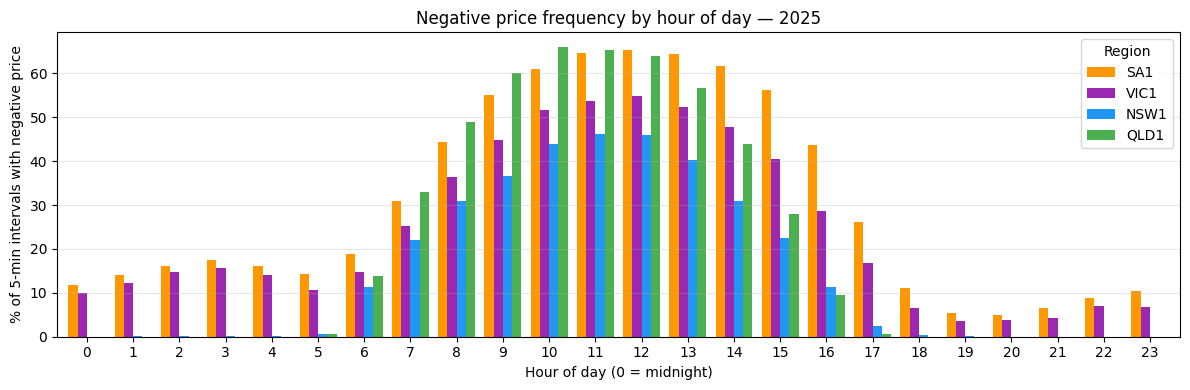


Peak negative price hour by region:
  SA1: hour 12:00 — 65.4% of intervals
  VIC1: hour 12:00 — 54.8% of intervals
  NSW1: hour 11:00 — 46.1% of intervals
  QLD1: hour 10:00 — 66.1% of intervals


In [44]:
# Negative price frequency by hour of day
# Negative prices occur when there is excess generation that cannot be curtailed
# (e.g. must-run wind/solar during low-demand periods). Generators bid negative
# to avoid being dispatched off and losing production tax credits or RPO compliance.
# High negative price frequency in midday hours → solar-driven curtailment pressure.
# SA and VIC should show a pronounced midday trough; QLD may differ due to solar mix.
neg_by_hour = (prices_wide < 0).groupby(prices_wide.index.hour).mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
neg_by_hour[['SA1', 'VIC1', 'NSW1', 'QLD1']].plot(
    kind='bar', ax=ax,
    color=['#FF9800', '#9C27B0', '#2196F3', '#4CAF50'],
    width=0.8
)
ax.set_xlabel('Hour of day (0 = midnight)')
ax.set_ylabel('% of 5-min intervals with negative price')
ax.set_title('Negative price frequency by hour of day — 2025')
ax.legend(title='Region')
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(range(24), rotation=0)
plt.tight_layout()
plt.show()

print("\nPeak negative price hour by region:")
for region in ['SA1', 'VIC1', 'NSW1', 'QLD1']:
    peak_hour = neg_by_hour[region].idxmax()
    peak_pct = neg_by_hour[region].max()
    print(f"  {region}: hour {peak_hour:02d}:00 — {peak_pct:.1f}% of intervals")